# VN100 Quantamental MLflow Research Notebook

This notebook adapts the Clinic 05-07 quantamental workflow to the local `QTradeSystematic` codebase. It uses QTS-native data sources, feature primitives, portfolio constructors, and backtest metrics where possible.

Workflow:

1. Fetch historical OHLCV and annual fundamentals for VN100 stocks.
2. Build qsmom, technical indicators, and fundamental factor features.
3. Apply reusable preprocessing and universe screening steps.
4. Run XGBoost walk-forward training with configurable portfolio construction.
5. Sweep model, feature, and portfolio parameters.
6. Log metrics, params, signals, returns, and equity curves to MLflow.

The default universe is a VN100 seed list from public index component snapshots. Replace it with an official HOSE constituent file when you need exact rebalance-date membership.


## Setup

Run this notebook from `QTradeSystematic/` so the local `qts` package is importable. If you start Jupyter from the parent folder, the setup cell below will still discover the project root.

MLflow logs to the Docker Compose tracking server by default at `http://127.0.0.1:5001`. Start the shared server before running experiment cells:

```bash
docker compose -f docker/compose.yaml up -d mlflow
```

For host `.venv` notebooks, no `MLFLOW_TRACKING_URI` override is needed. For notebooks running inside the Compose network, use `MLFLOW_TRACKING_URI=http://mlflow:5000`.

For a quick verification run, launch the notebook with small-scope environment variables such as `QTS_NOTEBOOK_MAX_SYMBOLS=6` and `QTS_NOTEBOOK_RUN_SWEEPS=0`.


In [1]:
from __future__ import annotations

import asyncio
import importlib.util
import math
import os
import sys
import threading
import warnings
from copy import deepcopy
from dataclasses import dataclass
from datetime import date, timedelta
from decimal import Decimal
from itertools import product
from pathlib import Path
from typing import Any
from urllib.parse import urlparse


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "qts").exists() and (candidate / "pyproject.toml").exists():
            return candidate
        nested = candidate / "QTradeSystematic"
        if (nested / "qts").exists() and (nested / "pyproject.toml").exists():
            return nested
    raise FileNotFoundError("Could not find the QTradeSystematic project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("QTS_ROOT", str(PROJECT_ROOT / ".qts_notebook_runtime"))
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import display

import qts  # noqa: F401 - imports registry side effects
from qts.data._schemas import DataType
from qts.data.manager import DataManager
from qts.data.sources.vnstock import VnstockDataSource
from qts.data.storage.duckdb import DuckDBStorage
from qts.data.storage.parquet import ParquetStorage
from qts.research.backtest._runner import _rebalance_dates, run_backtest_frame
from qts.research.backtest.base import BacktestConfig, CommissionConfig, UniverseConfig
from qts.research.backtest.metrics import build_metrics
from qts.research.features.forward_returns import ForwardReturns
from qts.research.features.fundamentals import (
    CANONICAL_FUNDAMENTAL_COLUMNS,
    FUNDAMENTAL_FACTOR_GROUPS,
    VNFundamentalFeatures,
    add_factor_scores as add_fundamental_factor_scores,
)
from qts.research.features.indicators.momentum import ROCFeature, RSIFeature
from qts.research.features.indicators.trend import MACDFeature
from qts.research.features.indicators.volatility import ATRFeature, HistVolFeature
from qts.research.features.preprocessor import flag_anomalies, preprocess_ohlcv, remove_flagged_symbols
from qts.research.strategies.base import BaseStrategy
from qts.research.strategies.factor.algorithms import train_and_predict_xgb_regressor
from qts.research.strategies.factor.portfolio_construction import long_short_equal_weight_portfolio
from qts.utils.paths import cache_dir

MLFLOW_AVAILABLE = importlib.util.find_spec("mlflow") is not None
if MLFLOW_AVAILABLE:
    import mlflow
else:
    mlflow = None

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:,.4f}".format

RUNTIME_ROOT = PROJECT_ROOT / ".qts_notebook_runtime" / "vn100_quantamental_mlflow"
RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)


def env_int(name: str, default: int | None = None) -> int | None:
    value = os.environ.get(name)
    if value is None or value.strip() == "":
        return default
    parsed = int(value)
    return parsed if parsed > 0 else None


def env_bool(name: str, default: bool = False) -> bool:
    value = os.environ.get(name)
    if value is None or value.strip() == "":
        return default
    return value.strip().lower() in {"1", "true", "yes", "y", "on"}


def env_date(name: str, default: date) -> date:
    value = os.environ.get(name)
    return default if value is None or value.strip() == "" else date.fromisoformat(value)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RUNTIME_ROOT: {RUNTIME_ROOT}")
print(f"MLFLOW_AVAILABLE: {MLFLOW_AVAILABLE}")


def run_async(coro):
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(coro)

    result: dict[str, Any] = {}
    error: dict[str, BaseException] = {}

    def runner() -> None:
        try:
            result["value"] = asyncio.run(coro)
        except BaseException as exc:
            error["value"] = exc

    thread = threading.Thread(target=runner, daemon=True)
    thread.start()
    thread.join()

    if "value" in error:
        raise error["value"]
    return result["value"]


/Users/s2997726/Desktop/code/quant/QS/QTradeSystematic/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /Users/s2997726/Desktop/code/quant/QS/QTradeSystematic
RUNTIME_ROOT: /Users/s2997726/Desktop/code/quant/QS/QTradeSystematic/.qts_notebook_runtime/vn100_quantamental_mlflow
MLFLOW_AVAILABLE: True


## VN100 Universe

The symbols are loaded from `configs/assets/vn100.yml`. Keep that file as the source of truth for the VN100 research universe and update it when you want a different constituent snapshot.


In [2]:
VN100_CONFIG_PATH = PROJECT_ROOT / "configs" / "assets" / "vn100.yml"
MAX_SYMBOLS: int | None = env_int("QTS_NOTEBOOK_MAX_SYMBOLS")


def normalize_vn_symbol(symbol: str, prefix: str = "VN:") -> str:
    raw = str(symbol).strip().upper()
    normalized_prefix = prefix.upper()
    return raw if raw.startswith(normalized_prefix) else f"{normalized_prefix}{raw}"


def load_vn100_config(path: Path = VN100_CONFIG_PATH) -> dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"VN100 asset config not found: {path}")
    config = yaml.safe_load(path.read_text()) or {}
    symbols = config.get("symbols") or []
    if not isinstance(symbols, list) or not symbols:
        raise ValueError(f"{path} must define a non-empty symbols list")
    return config


def load_vn100_symbols(path: Path = VN100_CONFIG_PATH) -> tuple[list[str], str]:
    config = load_vn100_config(path)
    prefix = str(config.get("symbol_prefix", "VN:"))
    symbols = [normalize_vn_symbol(item, prefix=prefix) for item in config["symbols"]]
    symbols = list(dict.fromkeys(symbols))
    benchmark = normalize_vn_symbol(config.get("benchmark_symbol", "VN100"), prefix=prefix)
    if MAX_SYMBOLS is not None:
        symbols = symbols[:MAX_SYMBOLS]
    return symbols, benchmark


VN100_SYMBOLS, BENCHMARK_SYMBOL = load_vn100_symbols()
REQUEST_SYMBOLS = VN100_SYMBOLS + [BENCHMARK_SYMBOL]

print(f"VN100 config: {VN100_CONFIG_PATH}")
print(f"VN100 equity symbols: {len(VN100_SYMBOLS)}")
print(f"Benchmark symbol: {BENCHMARK_SYMBOL}")
print(f"First 12: {VN100_SYMBOLS[:12]}")


VN100 config: /Users/s2997726/Desktop/code/quant/QS/QTradeSystematic/configs/assets/vn100.yml
VN100 equity symbols: 100
Benchmark symbol: VN:VN100
First 12: ['VN:ACB', 'VN:CTS', 'VN:DBC', 'VN:SHB', 'VN:VCG', 'VN:VIX', 'VN:VND', 'VN:DCM', 'VN:DGC', 'VN:ANV', 'VN:BID', 'VN:BMP']


## Fetch Historical Prices and Fundamentals

`VnstockDataSource` calls the public KBS endpoints. OHLCV is stored in a notebook DuckDB database and parquet cache. Fundamentals are cached by the source under the QTS cache directory as tidy long-format annual statement files, then joined later with `VNFundamentalFeatures`.

For a first smoke run, use a shorter date range or set `MAX_SYMBOLS` above. A full VN100 fundamental crawl can take several minutes because the source rate-limits requests.


In [3]:
START_DATE = env_date("QTS_NOTEBOOK_START_DATE", date(2021, 1, 1))
END_DATE = env_date("QTS_NOTEBOOK_END_DATE", date.today())
INTERVAL = os.environ.get("QTS_NOTEBOOK_INTERVAL", "1d")
FUNDAMENTAL_TERMTYPE = env_int("QTS_NOTEBOOK_FUNDAMENTAL_TERMTYPE", 1) or 1
FUNDAMENTAL_PAGES = env_int("QTS_NOTEBOOK_FUNDAMENTAL_PAGES", 3) or 3
FORCE_REFRESH_FUNDAMENTALS = env_bool("QTS_NOTEBOOK_FORCE_REFRESH_FUNDAMENTALS", False)
FETCH_FUNDAMENTALS = env_bool("QTS_NOTEBOOK_FETCH_FUNDAMENTALS", True)


def make_vn_manager() -> DataManager:
    storage = DuckDBStorage(database=str(RUNTIME_ROOT / "vn100.duckdb"))
    cache = ParquetStorage(root=RUNTIME_ROOT / "cache")
    return DataManager(
        stock_source=None,
        crypto_source=None,
        vn_stock_source=VnstockDataSource.from_env(),
        storage=storage,
        cache=cache,
        bundle_adapter=None,
    )


async def fetch_ohlcv_resilient(
    manager: DataManager,
    symbols: list[str],
    start_date: date,
    end_date: date,
    interval: str = "1d",
    batch_size: int = 12,
) -> tuple[pl.DataFrame, list[tuple[str, str]]]:
    frames: list[pl.DataFrame] = []
    failures: list[tuple[str, str]] = []
    for start_idx in range(0, len(symbols), batch_size):
        batch = symbols[start_idx : start_idx + batch_size]
        try:
            frame = await manager.get_ohlcv(batch, start_date, end_date, interval=interval)
            if not frame.is_empty():
                frames.append(frame)
            continue
        except Exception as exc:
            print(f"Batch failed, retrying symbol-by-symbol: {batch} ({exc})")

        for symbol in batch:
            try:
                frame = await manager.get_ohlcv([symbol], start_date, end_date, interval=interval)
                if not frame.is_empty():
                    frames.append(frame)
            except Exception as exc:
                failures.append((symbol, str(exc)))

    if not frames:
        return pl.DataFrame(), failures
    return pl.concat(frames, how="vertical").unique(subset=["date", "symbol"], keep="last"), failures


async def fetch_prices_and_fundamentals(
    symbols: list[str],
    start_date: date,
    end_date: date,
) -> tuple[pl.DataFrame, list[tuple[str, str]]]:
    manager = make_vn_manager()
    ohlcv, failures = await fetch_ohlcv_resilient(manager, symbols, start_date, end_date, INTERVAL)
    if FETCH_FUNDAMENTALS:
        await manager.bulk_fetch_vn_fundamentals(
            [symbol for symbol in symbols if symbol != BENCHMARK_SYMBOL],
            termtype=FUNDAMENTAL_TERMTYPE,
            pages=FUNDAMENTAL_PAGES,
            force_refresh=FORCE_REFRESH_FUNDAMENTALS,
        )
    return ohlcv.sort(["symbol", "date"]), failures


print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Fetch fundamentals: {FETCH_FUNDAMENTALS}, force refresh: {FORCE_REFRESH_FUNDAMENTALS}")

ohlcv_all, fetch_failures = run_async(fetch_prices_and_fundamentals(REQUEST_SYMBOLS, START_DATE, END_DATE))
benchmark_ohlcv = ohlcv_all.filter(pl.col("symbol") == BENCHMARK_SYMBOL)
ohlcv = ohlcv_all.filter(pl.col("symbol") != BENCHMARK_SYMBOL)

print(f"Fetched OHLCV rows: {ohlcv.height:,}")
print(f"Fetched symbols: {ohlcv.select('symbol').n_unique():,}")
print(f"Benchmark rows: {benchmark_ohlcv.height:,}")
print(f"Failures: {len(fetch_failures)}")
if fetch_failures:
    display(pd.DataFrame(fetch_failures, columns=["symbol", "error"]).head(20))

display(ohlcv.head(12).to_pandas())


Date range: 2021-01-01 to 2026-05-17
Fetch fundamentals: True, force refresh: False
Fetched OHLCV rows: 131,897
Fetched symbols: 100
Benchmark rows: 1
Failures: 0


,date,symbol,open,high,low,close,volume
0,2021-01-04,VN:ACB,10.7119,10.8244,10.6931,10.7494,"10,776,300.0000"
1,2021-01-05,VN:ACB,10.7306,11.1058,10.6181,11.0120,"18,693,900.0000"
2,2021-01-06,VN:ACB,11.1434,11.4810,10.9933,11.2184,"15,883,900.0000"
3,2021-01-07,VN:ACB,11.2184,11.2559,11.1058,11.2184,"11,636,100.0000"
4,2021-01-08,VN:ACB,11.2372,11.4060,11.1809,11.3309,"15,519,300.0000"
5,2021-01-11,VN:ACB,11.4435,11.5936,11.3122,11.3872,"9,821,800.0000"
6,2021-01-12,VN:ACB,11.3497,11.3685,11.2372,11.2934,"9,277,600.0000"
7,2021-01-13,VN:ACB,11.3685,11.3872,11.1434,11.1996,"9,915,300.0000"
8,2021-01-14,VN:ACB,11.2184,11.2184,10.9558,11.1996,"8,491,200.0000"
9,2021-01-15,VN:ACB,11.2559,11.4060,11.2372,11.3497,"8,184,100.0000"


,symbol,start,end,rows,last_close,avg_volume
0,VN:KDH,2021-01-04,2026-05-15,1334,23.4000,"2,902,820.7646"
1,VN:VRE,2021-01-04,2026-05-15,1334,34.0000,"6,580,738.4558"
2,VN:MBB,2021-01-04,2026-05-15,1334,25.6500,"16,696,781.2594"
3,VN:KDC,2021-01-04,2026-05-15,1334,48.6000,"993,388.6807"
4,VN:PNJ,2021-01-04,2026-05-15,1334,67.3000,"850,624.4378"
5,VN:PDR,2021-01-04,2026-05-15,1334,16.5500,"8,666,557.1964"
6,VN:VIC,2021-01-04,2026-05-15,1334,228.0000,"3,509,647.0765"
7,VN:BID,2021-01-04,2026-05-15,1334,42.9500,"3,003,594.5277"
8,VN:SSI,2021-01-04,2026-05-15,1334,27.9000,"20,781,271.6642"
9,VN:DGW,2021-01-04,2026-05-15,1334,42.4000,"1,456,147.7511"


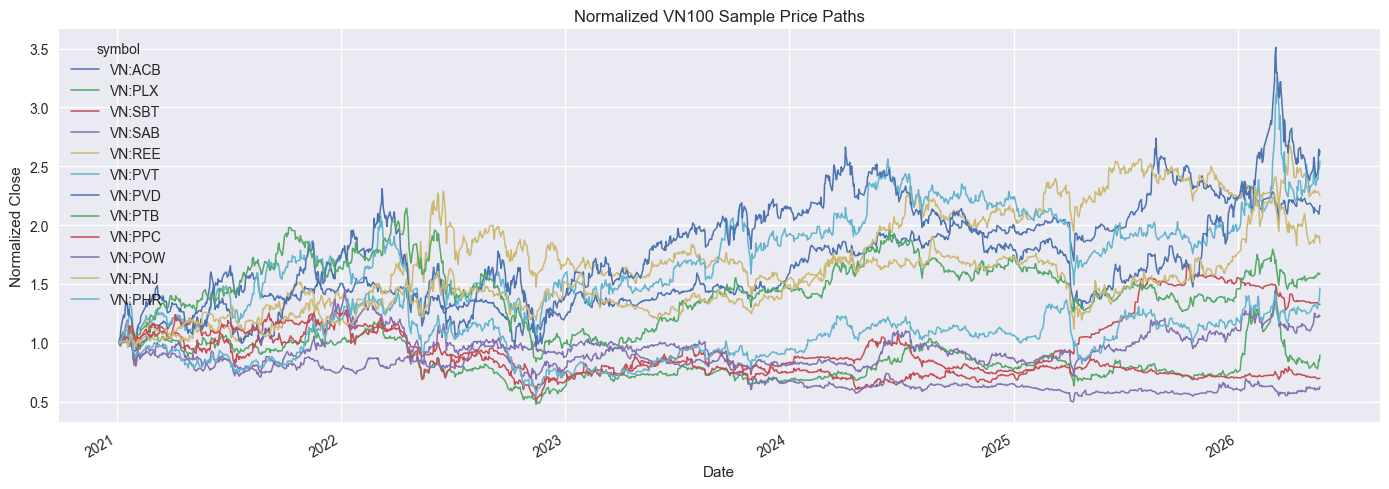

In [4]:
if ohlcv.is_empty():
    raise RuntimeError("No OHLCV rows were fetched. Check network access or reduce the universe.")

summary = (
    ohlcv.group_by("symbol")
    .agg(
        pl.col("date").min().alias("start"),
        pl.col("date").max().alias("end"),
        pl.len().alias("rows"),
        pl.col("close").last().alias("last_close"),
        pl.col("volume").mean().alias("avg_volume"),
    )
    .sort("rows", descending=True)
)
display(summary.head(20).to_pandas())

close_matrix = (
    ohlcv.select(["date", "symbol", "close"])
    .to_pandas()
    .pivot(index="date", columns="symbol", values="close")
    .sort_index()
)
plot_cols = close_matrix.notna().sum().sort_values(ascending=False).head(12).index
normalized = close_matrix[plot_cols].ffill().dropna(how="all")
normalized = normalized.div(normalized.iloc[0])

fig, ax = plt.subplots(figsize=(14, 5))
normalized.plot(ax=ax, lw=1.1)
ax.set_title("Normalized VN100 Sample Price Paths")
ax.set_ylabel("Normalized Close")
ax.set_xlabel("Date")
plt.tight_layout()


## Feature Engineering

The feature builder is split into explicit passes so each stage can be checked before training. Technical features are QTS-native, while HOSE/KBS fundamentals are normalized through `VNFundamentalFeatures` into the same FMP-like camelCase schema used by other equity markets. The diagnostics table below should keep rows and symbols non-zero through every pass.


In [5]:
@dataclass(frozen=True)
class FeatureConfig:
    min_trading_days: int = 252
    volume_top_n: int | None = 80
    min_avg_volume: float = 50_000
    remove_large_gaps: bool = False
    max_gap_days: int = 21
    remove_low_volume: bool = False
    qsmom_fast: int = 21
    qsmom_slow: int = 252
    qsmom_returns: int = 126
    forward_period: int = 21
    fundamental_termtype: int = 1


TECHNICAL_BASE_COLUMNS = [
    "roc_21",
    "roc_63",
    "roc_126",
    "roc_252",
    "rsi_14",
    "rsi_63",
    "macd_line",
    "macd_signal",
    "macd_hist",
    "atr_14",
    "hist_vol_21",
    "hist_vol_63",
    "hist_vol_126",
    "close_to_sma_50",
    "close_to_sma_200",
    "volume_ratio_20",
    "dollar_volume_zscore_63",
    "intraday_range",
    "close_location_value",
]

MODEL_PARAMS = {
    "random_state": 123,
    "objective": "reg:squarederror",
    "n_estimators": 120,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "n_jobs": -1,
}


def qsmom_column(config: FeatureConfig) -> str:
    return f"close_qsmom_{config.qsmom_fast}_{config.qsmom_slow}_{config.qsmom_returns}"


def technical_columns(config: FeatureConfig) -> list[str]:
    return [qsmom_column(config), *TECHNICAL_BASE_COLUMNS]


def default_predictor_candidates(config: FeatureConfig) -> list[str]:
    return [
        qsmom_column(config),
        "technicalCompositeFactor",
        "fundamentalCompositeFactor",
        "hybridCompositeFactor",
        *FUNDAMENTAL_FACTOR_GROUPS.keys(),
        "roc_63",
        "roc_252",
        "rsi_63",
        "macd_hist",
        "hist_vol_63",
        "hist_vol_126",
        "close_to_sma_50",
        "close_to_sma_200",
        "volume_ratio_20",
        "dollar_volume_zscore_63",
    ]


def available_predictors(df: pl.DataFrame, candidates: list[str]) -> list[str]:
    return [
        col
        for col in candidates
        if col in df.columns and df.select(pl.col(col).is_not_null().sum()).item() > 0
    ]


def effective_long_threshold(value: float | None) -> float:
    return -math.inf if value is None else float(value)


def screen_liquid_universe(df: pl.DataFrame, config: FeatureConfig) -> pl.DataFrame:
    if config.volume_top_n is None:
        return df
    latest_date = df["date"].max()
    lookback_start = latest_date - timedelta(days=365)
    liquidity = (
        df.filter(pl.col("date") >= lookback_start)
        .group_by("symbol")
        .agg(
            pl.col("volume").mean().alias("avg_volume"),
            pl.len().alias("rows"),
            pl.col("close").last().alias("last_close"),
        )
        .filter((pl.col("avg_volume") >= config.min_avg_volume) & (pl.col("rows") >= 120))
        .sort("avg_volume", descending=True)
        .head(config.volume_top_n)
    )
    keep = liquidity["symbol"].to_list()
    return df.filter(pl.col("symbol").is_in(keep))


def add_qsmom_features(df: pl.DataFrame, config: FeatureConfig) -> pl.DataFrame:
    fast = config.qsmom_fast
    slow = config.qsmom_slow
    returns = config.qsmom_returns
    out_col = qsmom_column(config)
    result = (
        df.sort(["symbol", "date"])
        .with_columns(
            ((pl.col("close") / pl.col("close").shift(1).over("symbol")) - 1).alias("_daily_return"),
            ((pl.col("close").shift(fast).over("symbol") / pl.col("close").shift(slow).over("symbol")) - 1).alias("_older_momentum"),
            ((pl.col("close") / pl.col("close").shift(fast).over("symbol")) - 1).alias("_recent_momentum"),
        )
        .with_columns(
            pl.col("_daily_return")
            .rolling_std(window_size=returns, min_samples=returns)
            .over("symbol")
            .alias("_return_vol")
        )
        .with_columns(
            ((pl.col("_older_momentum") - pl.col("_recent_momentum")) / (pl.col("_return_vol") + 1e-8)).alias(out_col)
        )
        .drop(["_daily_return", "_older_momentum", "_recent_momentum", "_return_vol"])
    )
    return result


def add_price_action_features(df: pl.DataFrame) -> pl.DataFrame:
    result = (
        df.sort(["symbol", "date"])
        .with_columns(
            pl.col("close").rolling_mean(20, min_samples=20).over("symbol").alias("sma_20"),
            pl.col("close").rolling_mean(50, min_samples=50).over("symbol").alias("sma_50"),
            pl.col("close").rolling_mean(200, min_samples=200).over("symbol").alias("sma_200"),
            pl.col("volume").rolling_mean(20, min_samples=20).over("symbol").alias("volume_sma_20"),
            (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
            ((pl.col("high") - pl.col("low")) / (pl.col("close") + 1e-8)).alias("intraday_range"),
            ((pl.col("close") - pl.col("low")) / (pl.col("high") - pl.col("low") + 1e-8)).alias("close_location_value"),
        )
        .with_columns(
            ((pl.col("close") / (pl.col("sma_50") + 1e-8)) - 1).alias("close_to_sma_50"),
            ((pl.col("close") / (pl.col("sma_200") + 1e-8)) - 1).alias("close_to_sma_200"),
            (pl.col("volume") / (pl.col("volume_sma_20") + 1e-8)).alias("volume_ratio_20"),
            (
                (pl.col("dollar_volume") - pl.col("dollar_volume").rolling_mean(63, min_samples=63).over("symbol"))
                / (pl.col("dollar_volume").rolling_std(63, min_samples=63).over("symbol") + 1e-8)
            ).alias("dollar_volume_zscore_63"),
        )
    )
    return result


def add_technical_features(df: pl.DataFrame) -> pl.DataFrame:
    result = df
    for feature in [
        ROCFeature(periods=[21, 63, 126, 252]),
        RSIFeature(periods=[14, 63]),
        MACDFeature(fast=50, slow=200, signal=30),
        ATRFeature(periods=[14]),
        HistVolFeature(periods=[21, 63, 126]),
    ]:
        result = feature.fit_transform(result)
    return add_price_action_features(result)


def _zscore_expr(column: str) -> pl.Expr:
    return (
        (pl.col(column) - pl.col(column).mean().over("date"))
        / (pl.col(column).std().over("date") + 1e-8)
    ).fill_nan(None).fill_null(0.0)


def add_factor_scores(df: pl.DataFrame, config: FeatureConfig) -> tuple[pl.DataFrame, dict[str, list[str]]]:
    result = df
    used: dict[str, list[str]] = {}

    tech_cols = [col for col in technical_columns(config) if col in result.columns]
    if tech_cols:
        result = result.with_columns(
            (sum(_zscore_expr(col) for col in tech_cols) / len(tech_cols)).alias("technicalCompositeFactor")
        )
        used["technicalCompositeFactor"] = tech_cols

    result, fundamental_sources = add_fundamental_factor_scores(result)
    used.update(fundamental_sources)

    hybrid_inputs = [col for col in ["technicalCompositeFactor", "fundamentalCompositeFactor"] if col in result.columns]
    if hybrid_inputs:
        result = result.with_columns(
            (sum(pl.col(col) for col in hybrid_inputs) / len(hybrid_inputs)).alias("hybridCompositeFactor")
        )
        used["hybridCompositeFactor"] = hybrid_inputs

    return result, used


def _stage_row(name: str, frame: pl.DataFrame, previous: pl.DataFrame | None = None) -> dict[str, Any]:
    symbols = frame.select("symbol").n_unique() if "symbol" in frame.columns and frame.height else 0
    previous_symbols = previous.select("symbol").n_unique() if previous is not None and "symbol" in previous.columns and previous.height else None
    return {
        "stage": name,
        "rows": frame.height,
        "symbols": symbols,
        "columns": len(frame.columns),
        "rows_delta": None if previous is None else frame.height - previous.height,
        "symbols_delta": None if previous_symbols is None else symbols - previous_symbols,
    }


def build_model_frame(
    raw_ohlcv: pl.DataFrame,
    config: FeatureConfig,
    *,
    return_diagnostics: bool = False,
) -> tuple[pl.DataFrame, dict[str, list[str]]] | tuple[pl.DataFrame, dict[str, list[str]], pl.DataFrame]:
    diagnostics: list[dict[str, Any]] = [_stage_row("raw", raw_ohlcv)]

    screened = screen_liquid_universe(raw_ohlcv, config)
    diagnostics.append(_stage_row("liquidity_screen", screened, raw_ohlcv))

    cleaned = preprocess_ohlcv(screened, min_trading_days=config.min_trading_days)
    diagnostics.append(_stage_row("preprocess_ohlcv", cleaned, screened))

    flagged = flag_anomalies(cleaned, max_gap_days=config.max_gap_days, min_notional_usd=None)
    diagnostics.append(_stage_row("flag_anomalies", flagged, cleaned))

    cleaned = remove_flagged_symbols(
        flagged,
        remove_large_gaps=config.remove_large_gaps,
        remove_low_volume=config.remove_low_volume,
    )
    diagnostics.append(_stage_row("remove_flagged_symbols", cleaned, flagged))

    featured = add_qsmom_features(cleaned, config)
    diagnostics.append(_stage_row("qsmom", featured, cleaned))

    featured = add_technical_features(featured)
    diagnostics.append(_stage_row("technical_features", featured))

    featured = VNFundamentalFeatures(termtype=config.fundamental_termtype).fit_transform(featured)
    diagnostics.append(_stage_row("fundamental_features", featured))

    featured, factor_sources = add_factor_scores(featured, config)
    diagnostics.append(_stage_row("factor_scores", featured))

    featured = ForwardReturns(periods=[config.forward_period]).fit_transform(featured)
    diagnostics.append(_stage_row("forward_returns", featured))

    result = featured.sort(["symbol", "date"])
    diagnostic_frame = pl.DataFrame(diagnostics)
    if return_diagnostics:
        return result, factor_sources, diagnostic_frame
    return result, factor_sources


def feature_coverage_report(df: pl.DataFrame, columns: list[str]) -> pl.DataFrame:
    rows = []
    total = max(df.height, 1)
    for column in columns:
        if column not in df.columns:
            rows.append({
                "column": column,
                "present": False,
                "dtype": None,
                "non_null": 0,
                "null_pct": 1.0,
                "finite_pct": 0.0,
                "n_unique": 0,
            })
            continue
        series = df[column]
        non_null = total - series.null_count()
        finite = df.select(pl.col(column).is_finite().sum()).item() if series.dtype.is_numeric() else non_null
        rows.append({
            "column": column,
            "present": True,
            "dtype": str(series.dtype),
            "non_null": int(non_null),
            "null_pct": float(series.null_count() / total),
            "finite_pct": float(finite / total),
            "n_unique": int(series.n_unique()),
        })
    return pl.DataFrame(rows)


def fundamental_cache_report(symbols: list[str], termtype: int = 1) -> pl.DataFrame:
    label = "annual" if termtype == 1 else "quarterly"
    rows = []
    for symbol in symbols:
        ticker = symbol.split(":", 1)[1] if ":" in symbol else symbol
        path = cache_dir() / "vn_fundamentals" / f"{ticker}_{label}.parquet"
        rows.append({
            "symbol": symbol,
            "cached": path.exists(),
            "path": str(path),
            "rows": pl.read_parquet(path).height if path.exists() else 0,
        })
    return pl.DataFrame(rows)


In [6]:
BASE_FEATURE_CONFIG = FeatureConfig(
    min_trading_days=252,
    volume_top_n=80,
    min_avg_volume=50_000,
    remove_large_gaps=False,
    max_gap_days=21,
    remove_low_volume=False,
    qsmom_fast=21,
    qsmom_slow=252,
    qsmom_returns=126,
    forward_period=21,
    fundamental_termtype=1,
)

featured, factor_sources, feature_diagnostics = build_model_frame(
    ohlcv,
    BASE_FEATURE_CONFIG,
    return_diagnostics=True,
)
TARGET_COLUMN = f"forward_return_{BASE_FEATURE_CONFIG.forward_period}"
EXPECTED_FEATURE_COLS = [
    *technical_columns(BASE_FEATURE_CONFIG),
    *CANONICAL_FUNDAMENTAL_COLUMNS,
    *FUNDAMENTAL_FACTOR_GROUPS.keys(),
    "technicalCompositeFactor",
    "fundamentalCompositeFactor",
    "hybridCompositeFactor",
    TARGET_COLUMN,
]
PREDICTOR_COLS = available_predictors(featured, default_predictor_candidates(BASE_FEATURE_CONFIG))
coverage = feature_coverage_report(featured, EXPECTED_FEATURE_COLS)
missing_expected = coverage.filter(~pl.col("present"))["column"].to_list()
empty_expected = coverage.filter(pl.col("present") & (pl.col("non_null") == 0))["column"].to_list()

print(f"Featured rows: {featured.height:,}")
print(f"Featured symbols: {featured.select('symbol').n_unique() if featured.height else 0:,}")
print(f"Target: {TARGET_COLUMN}")
print(f"Predictors ({len(PREDICTOR_COLS)}): {PREDICTOR_COLS}")
print(f"Missing expected columns: {missing_expected}")
print(f"Expected columns with zero data: {empty_expected}")
print("Factor source columns:")
for factor_name, columns in factor_sources.items():
    print(f"  {factor_name}: {columns[:12]}{' ...' if len(columns) > 12 else ''}")

print("Pipeline diagnostics:")
display(feature_diagnostics.to_pandas())

print("Feature coverage:")
display(coverage.to_pandas())

print("Fundamental cache coverage:")
display(fundamental_cache_report(VN100_SYMBOLS, termtype=BASE_FEATURE_CONFIG.fundamental_termtype).to_pandas().head(20))

if featured.is_empty() or not PREDICTOR_COLS:
    raise RuntimeError("Feature pipeline produced no usable predictors")
if missing_expected:
    raise RuntimeError(f"Missing expected feature columns: {missing_expected}")

preview_cols = [col for col in ["date", "symbol", "close", *PREDICTOR_COLS[:10], TARGET_COLUMN] if col in featured.columns]
display(featured.select(preview_cols).tail(12).to_pandas())


Featured rows: 106,116
Featured symbols: 80
Target: forward_return_21
Predictors (22): ['close_qsmom_21_252_126', 'technicalCompositeFactor', 'fundamentalCompositeFactor', 'hybridCompositeFactor', 'qualityFactor', 'valuationFactor', 'yieldFactor', 'growthFactor', 'leverageFactor', 'liquidityFactor', 'cashflowFactor', 'accrualQualityFactor', 'roc_63', 'roc_252', 'rsi_63', 'macd_hist', 'hist_vol_63', 'hist_vol_126', 'close_to_sma_50', 'close_to_sma_200', 'volume_ratio_20', 'dollar_volume_zscore_63']
Missing expected columns: []
Expected columns with zero data: []
Factor source columns:
  technicalCompositeFactor: ['close_qsmom_21_252_126', 'roc_21', 'roc_63', 'roc_126', 'roc_252', 'rsi_14', 'rsi_63', 'macd_line', 'macd_signal', 'macd_hist', 'atr_14', 'hist_vol_21'] ...
  qualityFactor: ['returnOnEquity', 'returnOnAssets', 'returnOnCapitalEmployed', 'grossProfitMargin', 'ebitMargin', 'netProfitMargin', 'cashReturnOnEquity', 'cashReturnOnAssets', 'interestCoverage']
  valuationFactor: ['pr

,stage,rows,symbols,columns,rows_delta,symbols_delta
0,raw,131897,100,7,NaN,NaN
1,liquidity_screen,106116,80,7,"-25,781.0000",-20.0000
2,preprocess_ohlcv,106116,80,7,0.0000,0.0000
3,flag_anomalies,106116,80,11,0.0000,0.0000
4,remove_flagged_symbols,106116,80,11,0.0000,0.0000
5,qsmom,106116,80,12,0.0000,0.0000
6,technical_features,106116,80,36,NaN,NaN
7,fundamental_features,106116,80,107,NaN,NaN
8,factor_scores,106116,80,118,NaN,NaN
9,forward_returns,106116,80,119,NaN,NaN


Feature coverage:


,column,present,dtype,non_null,null_pct,finite_pct,n_unique
0,close_qsmom_21_252_126,True,Float64,85956,0.1900,0.8100,85947
1,roc_21,True,Float64,104436,0.0158,0.9842,83919
2,roc_63,True,Float64,101076,0.0475,0.9525,89599
3,roc_126,True,Float64,96036,0.0950,0.9050,90084
4,roc_252,True,Float64,85956,0.1900,0.8100,83617
...,...,...,...,...,...,...,...
97,accrualQualityFactor,True,Float64,106116,0.0000,1.0000,3912
98,technicalCompositeFactor,True,Float64,106116,0.0000,1.0000,106116
99,fundamentalCompositeFactor,True,Float64,106116,0.0000,1.0000,4693
100,hybridCompositeFactor,True,Float64,106116,0.0000,1.0000,106116


Fundamental cache coverage:


,symbol,cached,path,rows
0,VN:ACB,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,567
1,VN:CTS,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,972
2,VN:DBC,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,741
3,VN:SHB,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,573
4,VN:VCG,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,864
5,VN:VIX,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,892
6,VN:VND,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,1024
7,VN:DCM,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,739
8,VN:DGC,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,748
9,VN:ANV,True,/Users/s2997726/Desktop/code/quant/QS/QTradeSy...,776


,date,symbol,close,close_qsmom_21_252_126,technicalCompositeFactor,fundamentalCompositeFactor,hybridCompositeFactor,qualityFactor,valuationFactor,yieldFactor,growthFactor,leverageFactor,liquidityFactor,forward_return_21
0,2026-04-28,VN:VSC,21.6500,23.4867,-0.1086,0.1893,0.0403,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
1,2026-04-29,VN:VSC,21.3500,21.2656,-0.2397,0.1893,-0.0252,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
2,2026-05-04,VN:VSC,21.6000,19.5082,-0.1457,0.1893,0.0218,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
3,2026-05-05,VN:VSC,21.4500,20.4126,-0.2558,0.1893,-0.0332,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
4,2026-05-06,VN:VSC,21.9000,19.1605,-0.2307,0.1893,-0.0207,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
5,2026-05-07,VN:VSC,22.0500,14.2996,-0.1842,0.1893,0.0025,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
6,2026-05-08,VN:VSC,22.1000,10.6384,-0.0851,0.1893,0.0521,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
7,2026-05-11,VN:VSC,22.6000,14.9216,-0.0150,0.1893,0.0871,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
8,2026-05-12,VN:VSC,22.0500,17.6535,-0.1106,0.1893,0.0394,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN
9,2026-05-13,VN:VSC,22.0000,17.5216,-0.1169,0.1893,0.0362,-0.0404,0.5220,-0.7452,0.0619,0.7568,0.8002,NaN


## One-Date ML Sanity Check

This trains one XGBoost model on all rows with known forward returns and predicts the latest complete cross-section. The walk-forward sweep below repeats this logic at each rebalance date.


In [7]:
def latest_complete_cross_section(
    df: pl.DataFrame,
    predictor_cols: list[str],
    min_symbols: int = 5,
) -> tuple[date, pl.DataFrame]:
    if not predictor_cols:
        raise RuntimeError("No usable predictor columns are available")
    for item in reversed(sorted(df["date"].unique().to_list())):
        predict = df.filter(pl.col("date") == item).drop_nulls(predictor_cols)
        if predict.height >= min_symbols:
            return item, predict
    coverage = feature_coverage_report(df, predictor_cols).sort("non_null")
    display(coverage.to_pandas())
    raise RuntimeError("No prediction date has enough complete predictor rows")


MIN_PREDICT_SYMBOLS = min(5, max(1, featured.select("symbol").n_unique()))
PREDICT_DATE, predict_data = latest_complete_cross_section(
    featured,
    PREDICTOR_COLS,
    min_symbols=MIN_PREDICT_SYMBOLS,
)
train_data = (
    featured
    .filter((pl.col("date") < PREDICT_DATE) & pl.col(TARGET_COLUMN).is_not_null())
    .drop_nulls(PREDICTOR_COLS + [TARGET_COLUMN])
)
if train_data.height < 100:
    raise RuntimeError(f"Need at least 100 training rows, found {train_data.height}")

scores = train_and_predict_xgb_regressor(
    train_data=train_data,
    predict_data=predict_data,
    predictor_cols=PREDICTOR_COLS,
    target_col=TARGET_COLUMN,
    model_params=MODEL_PARAMS,
)

prediction_preview = (
    predict_data.select(["date", "symbol", "close", *PREDICTOR_COLS])
    .with_columns(pl.Series("factor_signal", scores))
    .sort("factor_signal", descending=True)
)

weights = long_short_equal_weight_portfolio(
    predictions=pd.Series(scores, index=predict_data["symbol"].to_list()),
    num_long_positions=10,
    num_short_positions=0,
    long_threshold=effective_long_threshold(None),
)

print(f"Prediction date: {PREDICT_DATE}")
print(f"Train rows: {train_data.height:,}")
print(f"Predict rows: {predict_data.height:,}")
print("Top weights:", weights)
display(prediction_preview.head(15).to_pandas())


Prediction date: 2026-05-15
Train rows: 84,276
Predict rows: 80
Top weights: {'VN:VIC': 0.1, 'VN:FPT': 0.1, 'VN:CTD': 0.1, 'VN:PAN': 0.1, 'VN:POW': 0.1, 'VN:HPG': 0.1, 'VN:HAG': 0.1, 'VN:FTS': 0.1, 'VN:HSG': 0.1, 'VN:DBC': 0.1}


,date,symbol,close,close_qsmom_21_252_126,technicalCompositeFactor,fundamentalCompositeFactor,hybridCompositeFactor,qualityFactor,valuationFactor,yieldFactor,...,roc_252,rsi_63,macd_hist,hist_vol_63,hist_vol_126,close_to_sma_50,close_to_sma_200,volume_ratio_20,dollar_volume_zscore_63,factor_signal
0,2026-05-15,VN:VIC,228.0000,70.1758,3.5402,-0.2573,1.6415,-0.2997,0.5490,-0.7452,...,4.7431,63.8620,9.6545,0.0364,0.0370,0.3340,0.8044,0.8270,0.5331,0.1080
1,2026-05-15,VN:FPT,72.9000,-9.7110,-0.8625,0.0351,-0.4137,1.0524,-1.1952,-0.3451,...,-0.2781,42.8457,-1.5047,0.0231,0.0211,-0.0373,-0.2141,0.6198,-0.7459,0.0264
2,2026-05-15,VN:CTD,76.6000,5.8940,0.1860,-0.3042,-0.0591,-0.7625,0.4586,-0.7452,...,0.0875,49.4424,0.0012,0.0280,0.0255,-0.0325,0.0071,1.0021,0.4111,0.0173
3,2026-05-15,VN:PAN,32.9500,16.0139,0.5177,-0.0914,0.2132,-0.4063,0.6623,0.0550,...,0.4080,54.0104,0.1307,0.0228,0.0200,0.0404,0.0654,2.4736,1.9291,0.0172
4,2026-05-15,VN:POW,14.1000,5.8841,0.1838,-0.1568,0.0135,-0.6164,0.1831,-0.7452,...,0.3157,53.2494,-0.0172,0.0271,0.0247,0.0568,0.0914,0.5787,-0.5140,0.0167
5,2026-05-15,VN:HPG,26.5500,19.5818,0.0186,-0.1694,-0.0754,-0.1674,0.2368,-0.7452,...,0.2782,49.8118,-0.0111,0.0195,0.0173,-0.0086,-0.0105,2.4670,1.2308,0.0151
6,2026-05-15,VN:HAG,16.1000,11.6281,-0.3041,-0.2106,-0.2573,0.1060,0.3141,-0.7452,...,0.2243,49.3504,-0.0620,0.0184,0.0222,0.0092,-0.0219,0.9497,-0.4853,0.0144
7,2026-05-15,VN:FTS,26.6500,-6.5984,-0.6858,-0.2978,-0.4918,0.0000,-0.7291,-0.3451,...,-0.2242,44.1666,-0.1862,0.0251,0.0225,-0.0175,-0.1985,0.7924,-0.8208,0.0141
8,2026-05-15,VN:HSG,12.1000,-0.1592,-0.3608,0.1292,-0.1158,-0.7545,0.3572,0.4551,...,0.0503,49.1950,0.1864,0.0204,0.0189,0.0326,-0.0679,0.4989,-0.8965,0.0131
9,2026-05-15,VN:DBC,22.5500,-2.6295,-0.6362,0.1764,-0.2299,-0.0345,0.4077,-0.7452,...,-0.0927,44.4175,-0.3485,0.0199,0.0193,-0.0249,-0.1489,0.6441,-0.8521,0.0128


## Walk-Forward Backtest Helpers

Each config arm rebuilds the feature frame, trains on trailing history with known forward returns, predicts at each monthly rebalance date, converts scores into long-only equal weights, and sends the sparse signal frame through QTS's shared `run_backtest_frame` metric path.


In [8]:
class EmptyStrategy(BaseStrategy):
    def generate_signals(self, data: pl.DataFrame) -> pl.DataFrame:
        return self.empty_signal_frame()


@dataclass(frozen=True)
class ExperimentConfig:
    name: str
    feature: FeatureConfig
    predictor_cols: list[str] | None = None
    train_window: int = 504
    rebalance_frequency: str = "monthly"
    num_long_positions: int = 10
    num_short_positions: int = 0
    long_threshold: float | None = None
    short_threshold: float | None = None
    model_params: dict[str, Any] | None = None
    initial_capital: Decimal = Decimal("1000000000")


def choose_predictors(df: pl.DataFrame, config: FeatureConfig, explicit_cols: list[str] | None = None) -> list[str]:
    candidates = explicit_cols or default_predictor_candidates(config)
    return available_predictors(df, candidates)


def signals_from_weights(trade_date: date, weights: dict[str, float]) -> pl.DataFrame:
    rows = [
        {
            "date": trade_date,
            "symbol": symbol,
            "signal": 1 if weight > 0 else -1,
            "weight": abs(float(weight)),
        }
        for symbol, weight in weights.items()
        if float(weight) != 0.0
    ]
    if not rows:
        return BaseStrategy.empty_signal_frame()
    return EmptyStrategy().validate_signal_frame(pl.DataFrame(rows))


def walk_forward_ml_signals(
    df: pl.DataFrame,
    experiment: ExperimentConfig,
    predictor_cols: list[str],
    target_col: str,
) -> pl.DataFrame:
    all_dates = sorted(df["date"].unique().to_list())
    rebalance = _rebalance_dates(all_dates, experiment.rebalance_frequency)
    date_index = {item: idx for idx, item in enumerate(all_dates)}
    signal_frames: list[pl.DataFrame] = []
    model_params = experiment.model_params or MODEL_PARAMS

    for rebalance_date in rebalance:
        idx = date_index[rebalance_date]
        if idx < max(experiment.feature.qsmom_slow, experiment.feature.forward_period, 80):
            continue
        train_start = all_dates[max(0, idx - experiment.train_window)]
        train = (
            df.filter(
                (pl.col("date") >= train_start)
                & (pl.col("date") < rebalance_date)
                & pl.col(target_col).is_not_null()
            )
            .drop_nulls(predictor_cols + [target_col])
        )
        predict = df.filter(pl.col("date") == rebalance_date).drop_nulls(predictor_cols)
        min_predict_rows = max(2, min(experiment.num_long_positions, df.select("symbol").n_unique()))
        if train.height < 100 or predict.height < min_predict_rows:
            continue

        scores = train_and_predict_xgb_regressor(
            train_data=train,
            predict_data=predict,
            predictor_cols=predictor_cols,
            target_col=target_col,
            model_params=model_params,
        )
        predictions = pd.Series(scores, index=predict["symbol"].to_list())
        weights = long_short_equal_weight_portfolio(
            predictions=predictions,
            num_long_positions=experiment.num_long_positions,
            num_short_positions=experiment.num_short_positions,
            long_threshold=effective_long_threshold(experiment.long_threshold),
            short_threshold=experiment.short_threshold,
            history_df=train.to_pandas(),
        )
        signals = signals_from_weights(rebalance_date, weights)
        if not signals.is_empty():
            signal_frames.append(signals)

    if not signal_frames:
        return BaseStrategy.empty_signal_frame()
    return pl.concat(signal_frames, how="vertical").sort(["date", "symbol"])


def run_ml_factor_experiment(
    raw_ohlcv: pl.DataFrame,
    experiment: ExperimentConfig,
) -> dict[str, Any]:
    model_frame, factor_source_map, diagnostics = build_model_frame(
        raw_ohlcv,
        experiment.feature,
        return_diagnostics=True,
    )
    target_col = f"forward_return_{experiment.feature.forward_period}"
    predictor_cols = choose_predictors(model_frame, experiment.feature, experiment.predictor_cols)
    if not predictor_cols:
        raise RuntimeError(f"{experiment.name}: no predictor columns are available")
    signals = walk_forward_ml_signals(model_frame, experiment, predictor_cols, target_col)
    if signals.is_empty():
        raise RuntimeError(f"{experiment.name}: no signals generated")

    bt_config = BacktestConfig(
        workflow="research",
        asset_types=["vn_stock"],
        universe=UniverseConfig(vn_stock=sorted(model_frame["symbol"].unique().to_list())),
        start_date=model_frame["date"].min(),
        end_date=model_frame["date"].max(),
        initial_capital=experiment.initial_capital,
        backtest_engine="notebook",
        rebalance_frequency=experiment.rebalance_frequency,
        commission=CommissionConfig(model="percentage", rate=Decimal("0.0015")),
        calendar="XHOSE",
    )
    result = run_backtest_frame(
        engine_name="notebook_walk_forward",
        strategy=EmptyStrategy(),
        data=model_frame,
        config=bt_config,
        prebuilt_signals=signals,
    )
    return {
        "result": result,
        "model_frame": model_frame,
        "feature_diagnostics": diagnostics,
        "signals": signals,
        "predictor_cols": predictor_cols,
        "target_col": target_col,
        "factor_sources": factor_source_map,
    }


## MLflow Logging

If `mlflow` is not installed, the notebook still runs and displays results locally. Install the tracking extra with `pip install -e .[tracking]` or `pip install mlflow` to enable logging. By default, tracking goes to the shared Docker MLflow server at `http://127.0.0.1:5001`; set `MLFLOW_TRACKING_URI` only when running from a different network context.


In [9]:
DEFAULT_MLFLOW_TRACKING_URI = "http://127.0.0.1:5001"
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", DEFAULT_MLFLOW_TRACKING_URI)
MLFLOW_EXPERIMENT_NAME = os.environ.get("MLFLOW_EXPERIMENT_NAME", "VN100 Quantamental ML 2")
MLFLOW_ENABLED = MLFLOW_AVAILABLE and not env_bool("QTS_NOTEBOOK_DISABLE_MLFLOW", False)


def mlflow_artifact_location() -> str | None:
    scheme = urlparse(MLFLOW_TRACKING_URI).scheme
    if scheme in {"", "file", "sqlite"}:
        return (RUNTIME_ROOT / "mlartifacts").as_uri()
    return None


def setup_mlflow() -> None:
    if not MLFLOW_AVAILABLE:
        print("MLflow is not installed. Skipping tracking.")
        return
    if not MLFLOW_ENABLED:
        print("MLflow logging disabled by QTS_NOTEBOOK_DISABLE_MLFLOW.")
        return
    try:
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        if mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME) is None:
            artifact_location = mlflow_artifact_location()
            if artifact_location is None:
                mlflow.create_experiment(MLFLOW_EXPERIMENT_NAME)
            else:
                mlflow.create_experiment(MLFLOW_EXPERIMENT_NAME, artifact_location=artifact_location)
        mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
    except Exception as exc:
        print(f"MLflow setup failed for {MLFLOW_TRACKING_URI}; continuing without tracking: {exc}")
        print("Start the shared server with: docker compose -f docker/compose.yaml up -d mlflow")
        globals()["MLFLOW_ENABLED"] = False
        return
    print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
    print(f"MLflow experiment: {MLFLOW_EXPERIMENT_NAME}")


def flatten_params(payload: dict[str, Any], prefix: str = "") -> dict[str, Any]:
    flattened: dict[str, Any] = {}
    for key, value in payload.items():
        full_key = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, dict):
            flattened.update(flatten_params(value, full_key))
        else:
            flattened[full_key] = value
    return flattened


def mlflow_param_value(value: Any) -> str | int | float | bool | None:
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return repr(value)


def write_result_artifacts(run_dir: Path, payload: dict[str, Any]) -> list[Path]:
    run_dir.mkdir(parents=True, exist_ok=True)
    result = payload["result"]
    artifacts = {
        "returns.csv": result.returns.to_pandas(),
        "equity_curve.csv": result.equity_curve.to_pandas(),
        "signals.csv": payload["signals"].to_pandas(),
        "predictor_cols.csv": pd.DataFrame({"predictor_col": payload["predictor_cols"]}),
        "feature_diagnostics.csv": payload["feature_diagnostics"].to_pandas(),
        "factor_sources.csv": pd.DataFrame(
            [
                {"factor": factor, "source_columns": ",".join(columns)}
                for factor, columns in payload["factor_sources"].items()
            ]
        ),
    }
    paths = []
    for filename, frame in artifacts.items():
        path = run_dir / filename
        frame.to_csv(path, index=False)
        paths.append(path)
    return paths


def log_to_mlflow(experiment: ExperimentConfig, payload: dict[str, Any], extra_params: dict[str, Any]) -> None:
    if not MLFLOW_ENABLED:
        return
    result = payload["result"]
    params = {
        "name": experiment.name,
        "train_window": experiment.train_window,
        "rebalance_frequency": experiment.rebalance_frequency,
        "num_long_positions": experiment.num_long_positions,
        "num_short_positions": experiment.num_short_positions,
        "long_threshold": experiment.long_threshold,
        "short_threshold": experiment.short_threshold,
        "predictor_cols": payload["predictor_cols"],
        "target_col": payload["target_col"],
        "feature": experiment.feature.__dict__,
        "model_params": experiment.model_params or MODEL_PARAMS,
        **extra_params,
    }
    artifact_dir = RUNTIME_ROOT / "mlflow_artifacts" / experiment.name
    artifacts = write_result_artifacts(artifact_dir, payload)
    flat_params = {key: mlflow_param_value(value) for key, value in flatten_params(params).items()}
    try:
        with mlflow.start_run(run_name=experiment.name, tags={"asset_type": "vn_stock", "universe": "VN100"}):
            mlflow.log_params(flat_params)
            mlflow.log_metrics({key: float(value) for key, value in result.metrics.items()})
            mlflow.log_metric("signal_rows", float(payload["signals"].height))
            mlflow.log_metric("featured_rows", float(payload["model_frame"].height))
            for artifact in artifacts:
                mlflow.log_artifact(str(artifact))
    except Exception as exc:
        print(f"MLflow logging failed for {experiment.name}; continuing: {exc}")


setup_mlflow()


MLflow tracking URI: http://127.0.0.1:5001
MLflow experiment: VN100 Quantamental ML 2


## Run Baseline Experiment


🏃 View run baseline_qsmom_fundamental_xgb at: http://127.0.0.1:5001/#/experiments/2/runs/ef4045c445be4f02bc95bf16f1d3c6bc
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


,sharpe,sortino,cagr,max_drawdown,win_rate
baseline_qsmom_fundamental_xgb,0.5859,0.6267,-0.1966,0.9752,0.4483


,date,symbol,signal,weight
0,2025-02-03,VN:VND,1,0.1000
1,2025-03-03,VN:VND,1,0.1000
2,2025-08-01,VN:VND,1,0.1000
3,2025-11-03,VN:VND,1,0.1000
4,2025-12-01,VN:VND,1,0.1000
5,2022-04-01,VN:VNM,1,0.1000
6,2023-03-01,VN:VNM,1,0.1000
7,2023-09-05,VN:VNM,1,0.1000
8,2025-01-02,VN:VPB,1,0.1000
9,2022-05-04,VN:VPI,1,0.1000


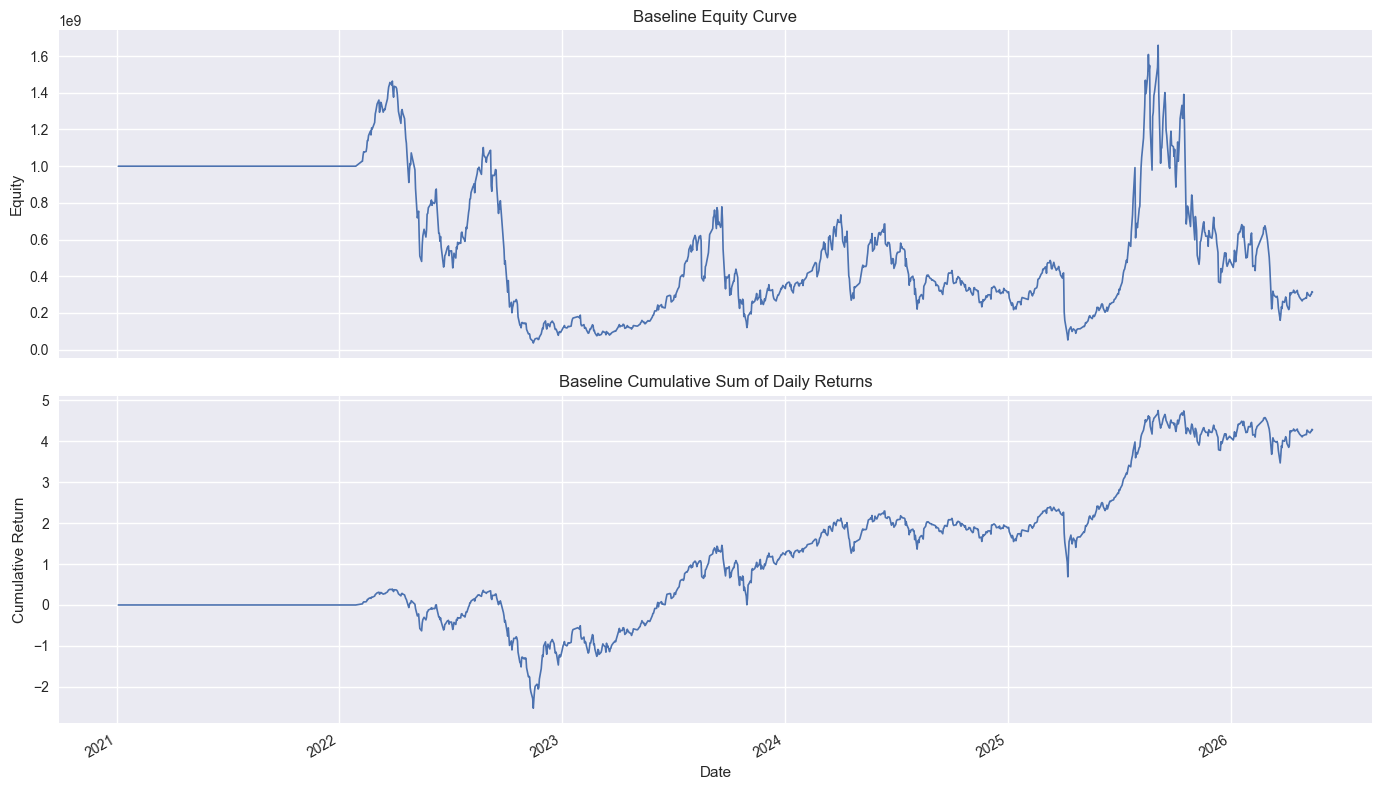

In [10]:
BASELINE_EXPERIMENT = ExperimentConfig(
    name="baseline_qsmom_fundamental_xgb",
    feature=BASE_FEATURE_CONFIG,
    train_window=504,
    rebalance_frequency="monthly",
    num_long_positions=10,
    num_short_positions=0,
    long_threshold=None,
    model_params=MODEL_PARAMS,
)

baseline_payload = run_ml_factor_experiment(ohlcv, BASELINE_EXPERIMENT)
log_to_mlflow(BASELINE_EXPERIMENT, baseline_payload, extra_params={"run_type": "baseline"})

baseline_result = baseline_payload["result"]
metrics_df = pd.DataFrame([baseline_result.metrics], index=[BASELINE_EXPERIMENT.name])
display(metrics_df)
display(baseline_result.signals.tail(20).to_pandas())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
baseline_result.equity_curve.to_pandas().set_index("date")["equity"].plot(ax=axes[0], lw=1.2)
axes[0].set_title("Baseline Equity Curve")
axes[0].set_ylabel("Equity")
baseline_result.returns.to_pandas().set_index("date")["portfolio_return"].cumsum().plot(ax=axes[1], lw=1.2)
axes[1].set_title("Baseline Cumulative Sum of Daily Returns")
axes[1].set_ylabel("Cumulative Return")
axes[1].set_xlabel("Date")
plt.tight_layout()


## Parameter Sweeps

The sweep arms mirror the lecture pattern: each arm changes a small set of feature, model, or portfolio parameters, runs a full walk-forward experiment, and logs a separate MLflow run.


In [11]:
RUN_SWEEPS = env_bool("QTS_NOTEBOOK_RUN_SWEEPS", True)

SWEEP_ARMS = [
    ExperimentConfig(
        name=f"vn100_top{top_n}_qsmom{fast}_{slow}_long{num_long}_depth{depth}",
        feature=FeatureConfig(
            min_trading_days=252,
            volume_top_n=top_n,
            min_avg_volume=50_000,
            remove_large_gaps=False,
            max_gap_days=21,
            remove_low_volume=False,
            qsmom_fast=fast,
            qsmom_slow=slow,
            qsmom_returns=126,
            forward_period=21,
            fundamental_termtype=1,
        ),
        train_window=504,
        rebalance_frequency="monthly",
        num_long_positions=num_long,
        num_short_positions=0,
        long_threshold=None,
        model_params={
            **MODEL_PARAMS,
            "max_depth": depth,
            "n_estimators": n_estimators,
        },
    )
    for top_n, fast, slow, num_long, depth, n_estimators in product(
        [50, 80],
        [21],
        [126, 252],
        [8, 12],
        [2, 3],
        [80],
    )
]

print(f"Prepared sweep arms: {len(SWEEP_ARMS)}")
print(SWEEP_ARMS[0])

if not RUN_SWEEPS:
    SWEEP_ARMS = []
    print("Sweep arms disabled by QTS_NOTEBOOK_RUN_SWEEPS=0")


Prepared sweep arms: 16
ExperimentConfig(name='vn100_top50_qsmom21_126_long8_depth2', feature=FeatureConfig(min_trading_days=252, volume_top_n=50, min_avg_volume=50000, remove_large_gaps=False, max_gap_days=21, remove_low_volume=False, qsmom_fast=21, qsmom_slow=126, qsmom_returns=126, forward_period=21, fundamental_termtype=1), predictor_cols=None, train_window=504, rebalance_frequency='monthly', num_long_positions=8, num_short_positions=0, long_threshold=None, short_threshold=None, model_params={'random_state': 123, 'objective': 'reg:squarederror', 'n_estimators': 80, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.85, 'n_jobs': -1}, initial_capital=Decimal('1000000000'))


In [12]:
sweep_rows = []
sweep_payloads: dict[str, dict[str, Any]] = {}

for experiment in SWEEP_ARMS:
    print(f"Running {experiment.name}")
    try:
        payload = run_ml_factor_experiment(ohlcv, experiment)
        log_to_mlflow(experiment, payload, extra_params={"run_type": "sweep"})
        sweep_payloads[experiment.name] = payload
        sweep_rows.append({
            "name": experiment.name,
            **payload["result"].metrics,
            "signal_rows": payload["signals"].height,
            "featured_rows": payload["model_frame"].height,
            "predictor_count": len(payload["predictor_cols"]),
            "status": "ok",
        })
    except Exception as exc:
        sweep_rows.append({"name": experiment.name, "status": "failed", "error": str(exc)})
        print(f"  failed: {exc}")

sweep_results_df = pd.DataFrame(sweep_rows)
if sweep_results_df.empty:
    print("No sweep runs were executed.")
else:
    metric_columns = [col for col in ["sharpe", "sortino", "cagr", "max_drawdown", "win_rate"] if col in sweep_results_df.columns]
    if metric_columns:
        display(sweep_results_df.sort_values("sharpe", ascending=False))
    else:
        display(sweep_results_df)


Running vn100_top50_qsmom21_126_long8_depth2
🏃 View run vn100_top50_qsmom21_126_long8_depth2 at: http://127.0.0.1:5001/#/experiments/2/runs/46fb7e00b655474ba808eac4790b16e3
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Running vn100_top50_qsmom21_126_long8_depth3
🏃 View run vn100_top50_qsmom21_126_long8_depth3 at: http://127.0.0.1:5001/#/experiments/2/runs/fbd3c35726bf4a23878b66e91af263b0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Running vn100_top50_qsmom21_126_long12_depth2
🏃 View run vn100_top50_qsmom21_126_long12_depth2 at: http://127.0.0.1:5001/#/experiments/2/runs/a3f5a5a48e6f451e8d080adf074ff356
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Running vn100_top50_qsmom21_126_long12_depth3
🏃 View run vn100_top50_qsmom21_126_long12_depth3 at: http://127.0.0.1:5001/#/experiments/2/runs/d3b4c1ef3b334a44a0308524091a4f8b
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Running vn100_top50_qsmom21_252_long8_depth2
🏃 View run vn100_to

,name,sharpe,sortino,cagr,max_drawdown,win_rate,signal_rows,featured_rows,predictor_count,status
13,vn100_top80_qsmom21_252_long8_depth3,0.6113,0.6573,-0.3638,0.9887,0.4460,416,106116,22,ok
9,vn100_top80_qsmom21_126_long8_depth3,0.6058,0.6483,-0.4038,0.9913,0.4468,416,106116,22,ok
12,vn100_top80_qsmom21_252_long8_depth2,0.6035,0.6452,-0.4330,0.9936,0.4483,416,106116,22,ok
11,vn100_top80_qsmom21_126_long12_depth3,0.5845,0.6238,-0.0607,0.9699,0.4513,624,106116,22,ok
10,vn100_top80_qsmom21_126_long12_depth2,0.5750,0.6159,-0.1013,0.9775,0.4468,624,106116,22,ok
14,vn100_top80_qsmom21_252_long12_depth2,0.5717,0.6134,-0.1224,0.9753,0.4438,624,106116,22,ok
15,vn100_top80_qsmom21_252_long12_depth3,0.5698,0.6085,-0.1063,0.9729,0.4483,624,106116,22,ok
4,vn100_top50_qsmom21_252_long8_depth2,0.5613,0.6118,-0.1147,0.9639,0.4438,416,66640,22,ok
8,vn100_top80_qsmom21_126_long8_depth2,0.5354,0.5772,-0.4818,0.9950,0.4438,416,106116,22,ok
0,vn100_top50_qsmom21_126_long8_depth2,0.5330,0.5828,-0.1383,0.9694,0.4408,416,66640,22,ok


Best run by Sharpe: vn100_top80_qsmom21_252_long8_depth3


,name,sharpe,sortino,cagr,max_drawdown,win_rate,signal_rows,featured_rows,predictor_count,status
13,vn100_top80_qsmom21_252_long8_depth3,0.6113,0.6573,-0.3638,0.9887,0.4460,416,106116,22,ok


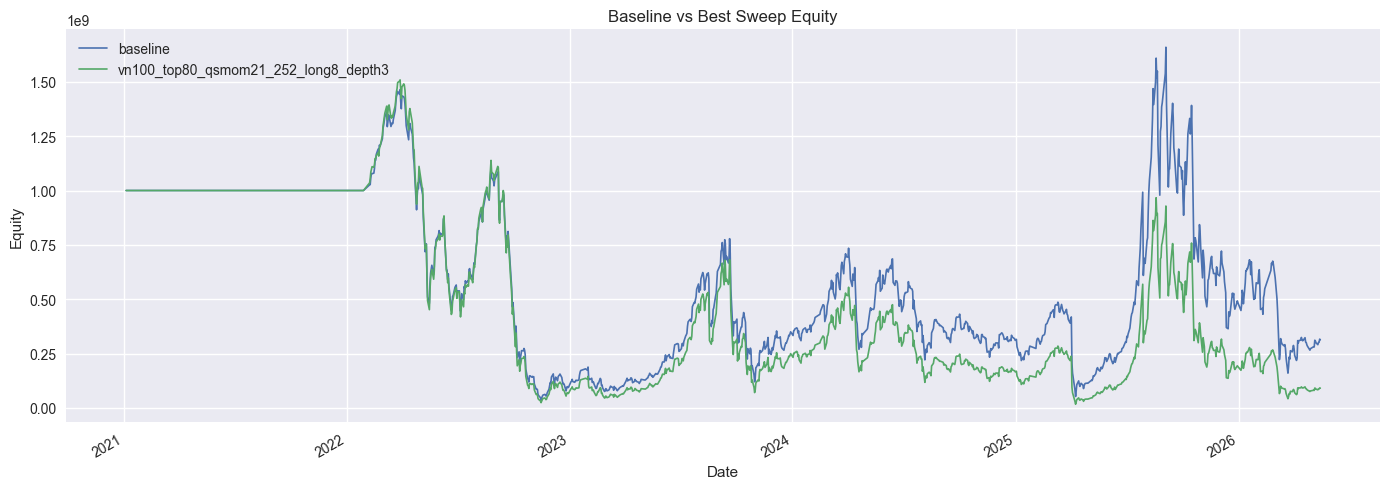

In [13]:
if "status" not in sweep_results_df.columns:
    print("No successful sweep runs to compare.")
else:
    ok_results = sweep_results_df[sweep_results_df["status"] == "ok"].copy()
    if not ok_results.empty:
        best_name = ok_results.sort_values("sharpe", ascending=False).iloc[0]["name"]
        best_payload = sweep_payloads[best_name]
        print(f"Best run by Sharpe: {best_name}")
        display(ok_results[ok_results["name"] == best_name])

        comparison = pd.concat(
            {
                "baseline": baseline_result.equity_curve.to_pandas().set_index("date")["equity"],
                best_name: best_payload["result"].equity_curve.to_pandas().set_index("date")["equity"],
            },
            axis=1,
        ).sort_index()

        fig, ax = plt.subplots(figsize=(14, 5))
        comparison.plot(ax=ax, lw=1.2)
        ax.set_title("Baseline vs Best Sweep Equity")
        ax.set_ylabel("Equity")
        ax.set_xlabel("Date")
        plt.tight_layout()
    else:
        print("No successful sweep runs to compare.")


## Show Results in MLflow

After the sweep finishes, open the MLflow UI at `http://127.0.0.1:5001`. The cell below also pulls the latest experiment table directly from MLflow when the package is installed.


## Notes and Next Steps

- The embedded VN100 list is a research seed list. For production-quality historical studies, load point-in-time constituents from HOSE or a maintained vendor file.
- `VNFundamentalFeatures` joins KBS annual ratio rows backward by report date to reduce look-ahead bias.
- If no fundamental factors appear, refresh the fundamentals cache or inspect the raw cached files under the QTS cache directory.
- Promote the best sweep arm into YAML once the feature set and portfolio construction rules are stable.
